### 1: Dataset Overview

In [131]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import os

DB_PATH = "../database/chinese_medical_devices.db"
conn = sqlite3.connect(DB_PATH)
print("Connected.")

Connected.


In [133]:
print("=" * 60)
print("MODULE 1: DATASET OVERVIEW")
print("=" * 60)

# 1.1 Deduplication summary
rows_after = conn.execute("SELECT COUNT(*) FROM devices").fetchone()[0]
rows_removed = 445
rows_before = rows_after + rows_removed

dedup_summary = pd.DataFrame({
    "Stage": [
        "After initial load (before deduplication)",
        "Duplicate rows removed (same device_record_key)",
        "After deduplication (final)"
    ],
    "Row Count": [
        f"{rows_before:,}",
        f"{rows_removed:,}",
        f"{rows_after:,}"
    ]
})
print("\n--- 1.1 Deduplication Summary ---")
display(dedup_summary)

# 1.2 Missing value ratio (based on 50,000 sampled rows)
df_sample = pd.read_sql(
    "SELECT * FROM devices ORDER BY RANDOM() LIMIT 50000", conn
)
missing_df = pd.DataFrame({
    "Column":            df_sample.columns,
    "Data Type":         df_sample.dtypes.astype(str).values,
    "Non-Null Count":    df_sample.notnull().sum().values,
    "Missing Count":     df_sample.isnull().sum().values,
    "Missing Ratio (%)": (df_sample.isnull().mean() * 100).round(2).values
}).reset_index(drop=True)
missing_df.index += 1
missing_df = missing_df.sort_values(
    "Missing Ratio (%)", ascending=False
).reset_index(drop=True)
missing_df.index += 1

print("\n--- 1.2 Missing Value Summary (50,000 sampled rows) ---")
display(missing_df)

# 1.3 Database basic info
db_size_gb   = os.path.getsize(DB_PATH) / 1024 ** 3
col_count    = len(df_sample.columns)
source_files = conn.execute(
    "SELECT COUNT(DISTINCT source_file) FROM devices"
).fetchone()[0]

db_info = pd.DataFrame({
    "Metric": ["Database Size", "Column Count", "Source XML Files", "Total Records"],
    "Value":  [f"{db_size_gb:.2f} GB", col_count, f"{source_files:,}", f"{rows_after:,}"]
})
print("\n--- 1.3 Database Info ---")
display(db_info)

MODULE 1: DATASET OVERVIEW

--- 1.1 Deduplication Summary ---


,Stage,Row Count
0,After initial load (before deduplication),"5,674,158"
1,Duplicate rows removed (same device_record_key),445
2,After deduplication (final),"5,673,713"



--- 1.2 Missing Value Summary (50,000 sampled rows) ---


,Column,Data Type,Non-Null Count,Missing Count,Missing Ratio (%)
1,packingList,object,0,50000,100.00
2,clinicalList,object,0,50000,100.00
3,storageList,object,0,50000,100.00
4,special_date,object,451,49549,99.10
5,registration_product_code,object,695,49305,98.61
6,special_storage_notes,object,819,49181,98.36
7,max_reuse_times,object,838,49162,98.32
8,additional_info_url,object,1245,48755,97.51
9,companion_device_code,object,1396,48604,97.21
10,correction_remark,object,1486,48514,97.03



--- 1.3 Database Info ---


,Metric,Value
0,Database Size,3.99 GB
1,Column Count,56
2,Source XML Files,"1,136"
3,Total Records,"5,673,713"


### 2: Time Trend Analysis

In [134]:
conn = sqlite3.connect("../database/chinese_medical_devices.db")

# Full record count by year
yearly_full = pd.read_sql("""
    SELECT
        SUBSTR(udi_publish_date, 1, 4) AS year,
        COUNT(*) AS record_count
    FROM devices
    WHERE udi_publish_date IS NOT NULL
    GROUP BY year
    ORDER BY year
""", conn)

display(yearly_full)
conn.close()

,year,record_count
0,2001,2
1,2005,1
2,2007,132
3,2010,132
4,2013,6
5,2014,46
6,2015,102
7,2016,1
8,2018,478
9,2019,701


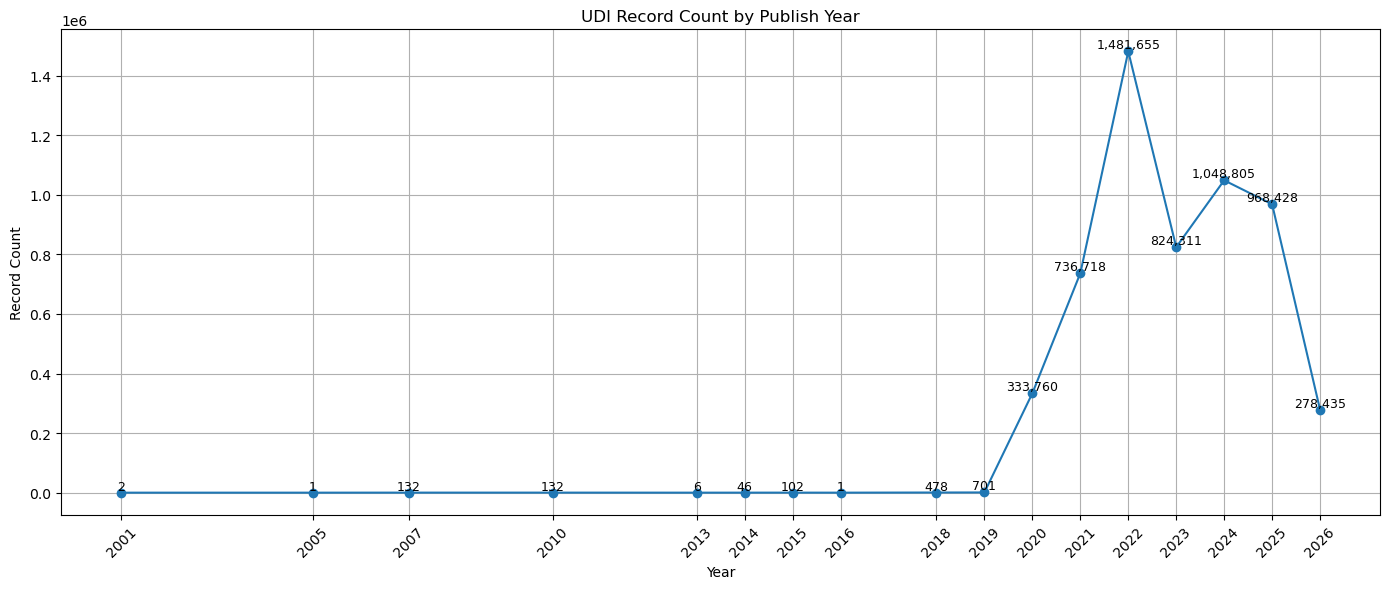

In [99]:
import matplotlib.pyplot as plt
import sqlite3
import pandas as pd

conn = sqlite3.connect("../database/chinese_medical_devices.db")

yearly = pd.read_sql("""
    SELECT
        SUBSTR(udi_publish_date, 1, 4) AS year,
        COUNT(*) AS count
    FROM devices
    WHERE udi_publish_date IS NOT NULL
    GROUP BY year
    ORDER BY year
""", conn)
conn.close()

# Clean up
yearly = yearly.dropna()
yearly["year"] = yearly["year"].astype(int)
yearly = yearly.sort_values("year")

# Plot
plt.figure(figsize=(14, 6))
plt.plot(
    yearly["year"],
    yearly["count"],
    marker="o"
)

# Add count labels to each point
for i in range(len(yearly)):
    plt.text(
        yearly["year"].iloc[i],
        yearly["count"].iloc[i],
        f"{yearly['count'].iloc[i]:,}",
        fontsize=9,
        ha="center",
        va="bottom"
    )

plt.title("UDI Record Count by Publish Year")
plt.xlabel("Year")
plt.ylabel("Record Count")
plt.xticks(yearly["year"], rotation=45)
plt.grid(True)
plt.tight_layout()
plt.savefig(
    "../outputs/udi_publish_year_trend.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### 3: Top20 product types

In [111]:
conn = sqlite3.connect("../database/chinese_medical_devices.db")

unique_count = conn.execute(
    "SELECT COUNT(DISTINCT product_generic_name) FROM devices"
).fetchone()[0]

conn.close()
print(f"Unique product generic names: {unique_count:,}")

Unique product generic names: 102,702


In [109]:
conn = sqlite3.connect("../database/chinese_medical_devices.db")

top_products = pd.read_sql("""
    SELECT
        product_generic_name,
        COUNT(*) AS count
    FROM devices
    WHERE product_generic_name IS NOT NULL
    GROUP BY product_generic_name
    ORDER BY count DESC
    LIMIT 20
""", conn)

conn.close()
print(top_products.to_string(index=False))

product_generic_name   count
             软性亲水接触镜 1251359
                金属骨针  140886
           金属锁定接骨板系统   86073
     一次性使用精密过滤输液器 带针   72190
              金属接骨螺钉   67950
                骨牵引针   62298
           脊柱后路内固定系统   60659
               椎间融合器   56775
             颅骨修补植入物   52255
               合成树脂牙   47378
             脊柱内固定系统   41005
               带锁髓内钉   40328
           金属非锁定接骨螺钉   37188
            可吸收性外科缝线   35436
             金属带锁髓内钉   35280
         一次性使用输液器 带针   32760
               骨科用锯片   32678
       一次性使用无菌注射器 带针   30957
         胸腰后路钉棒内固定系统   28371
             定制式固定义齿   26522


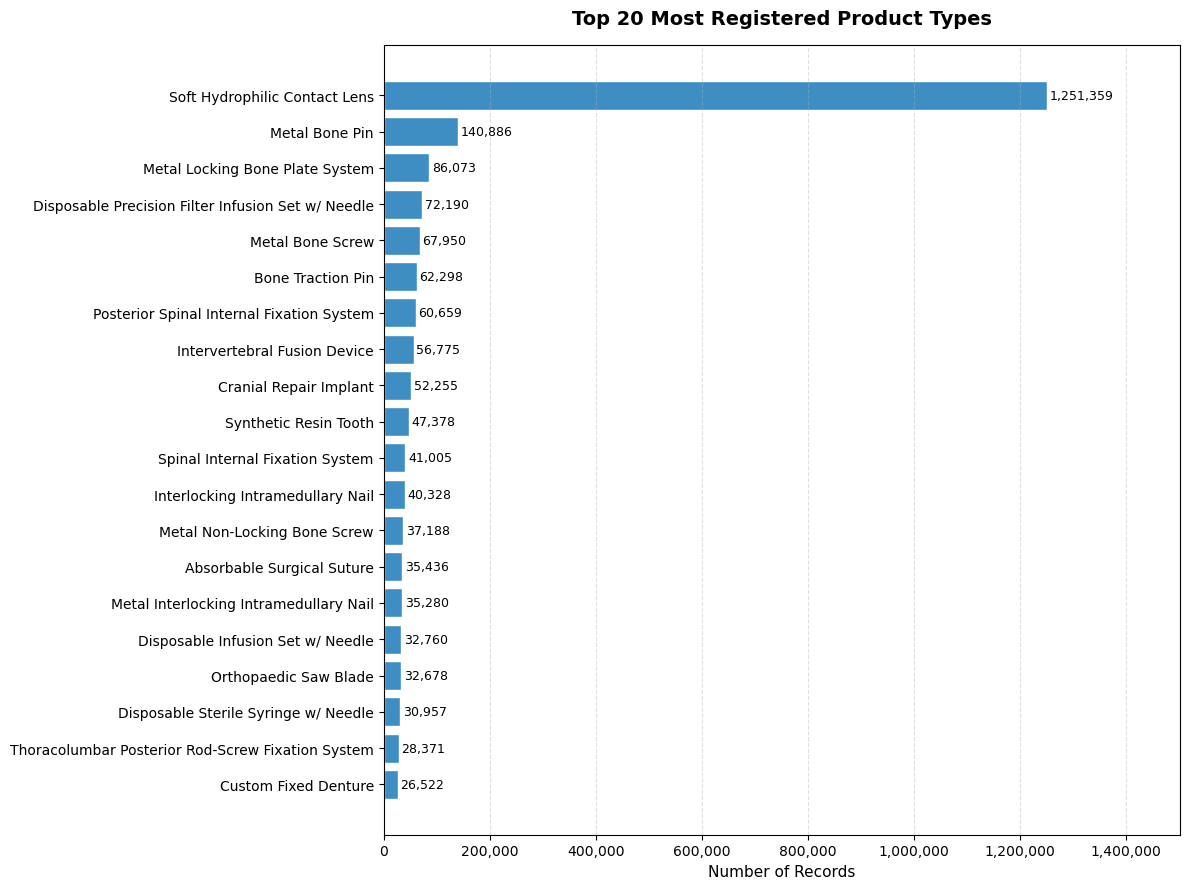

In [115]:
name_mapping_products = {
    '软性亲水接触镜':           'Soft Hydrophilic Contact Lens',
    '金属骨针':                 'Metal Bone Pin',
    '金属锁定接骨板系统':       'Metal Locking Bone Plate System',
    '一次性使用精密过滤输液器 带针': 'Disposable Precision Filter Infusion Set w/ Needle',
    '金属接骨螺钉':             'Metal Bone Screw',
    '骨牵引针':                 'Bone Traction Pin',
    '脊柱后路内固定系统':       'Posterior Spinal Internal Fixation System',
    '椎间融合器':               'Intervertebral Fusion Device',
    '颅骨修补植入物':           'Cranial Repair Implant',
    '合成树脂牙':               'Synthetic Resin Tooth',
    '脊柱内固定系统':           'Spinal Internal Fixation System',
    '带锁髓内钉':               'Interlocking Intramedullary Nail',
    '金属非锁定接骨螺钉':       'Metal Non-Locking Bone Screw',
    '可吸收性外科缝线':         'Absorbable Surgical Suture',
    '金属带锁髓内钉':           'Metal Interlocking Intramedullary Nail',
    '一次性使用输液器 带针':     'Disposable Infusion Set w/ Needle',
    '骨科用锯片':               'Orthopaedic Saw Blade',
    '一次性使用无菌注射器 带针': 'Disposable Sterile Syringe w/ Needle',
    '胸腰后路钉棒内固定系统':   'Thoracolumbar Posterior Rod-Screw Fixation System',
    '定制式固定义齿':           'Custom Fixed Denture',
}

top_products['product_en'] = top_products['product_generic_name'].map(name_mapping_products)

fig, ax = plt.subplots(figsize=(12, 9))
bars = ax.barh(
    top_products['product_en'][::-1],
    top_products['count'][::-1],
    color="#3E8EC4",
    edgecolor="white"
)

for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 5000,
        bar.get_y() + bar.get_height() / 2,
        f"{int(width):,}",
        va="center", ha="left", fontsize=9
    )

ax.set_title("Top 20 Most Registered Product Types",
             fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Number of Records", fontsize=11)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.grid(axis="x", linestyle="--", alpha=0.4)
ax.set_xlim(0, top_products['count'].max() * 1.2)
plt.tight_layout()
plt.savefig("../outputs/top20_products.png", dpi=300, bbox_inches="tight")
plt.show()

### Module 4 : Registrant & Regulatory Analysis
4.1 Top 15 Registrants by RecordCounts

In [25]:
conn = sqlite3.connect("../database/chinese_medical_devices.db")

top_reg = pd.read_sql("""
    SELECT
        registrant_name_cn,
        COUNT(*) AS count
    FROM devices
    WHERE registrant_name_cn IS NOT NULL
    GROUP BY registrant_name_cn
    ORDER BY count DESC
    LIMIT 15
""", conn)

top_reg.index = range(1, len(top_reg) + 1)

conn.close()
display(top_reg)

,registrant_name_cn,count
1,吉林瑞尔康光学科技有限公司,379507
2,山东威高骨科材料股份有限公司,240551
3,四川维思达医疗器械有限公司,185465
4,岳阳民康医用材料有限公司,109439
5,浙江德康医疗器械有限公司,93416
6,上海数健生物科技有限公司,79881
7,上海卫康光学眼镜有限公司,74387
8,常州健力邦德医疗器械有限公司,66314
9,江苏国立医疗器械有限公司,66159
10,江苏天眼医药科技股份有限公司,63484


,registrant_name_en,count
1,Jilin Ruierkang Optical Technology Co.,379507
2,Weigao Orthopaedic Materials Co.,240551
3,Sichuan Weisida Medical Devices Co.,185465
4,Yueyang Minkang Medical Materials Co.,109439
5,Zhejiang Dekang Medical Devices Co.,93416
6,Shanghai Shujian Biotech Co.,79881
7,Shanghai Weikang Optical Eyewear Co.,74387
8,Changzhou Jianli Bond Medical Co.,66314
9,Jiangsu Guoli Medical Devices Co.,66159
10,Jiangsu Tianyan Medical Technology Co.,63484


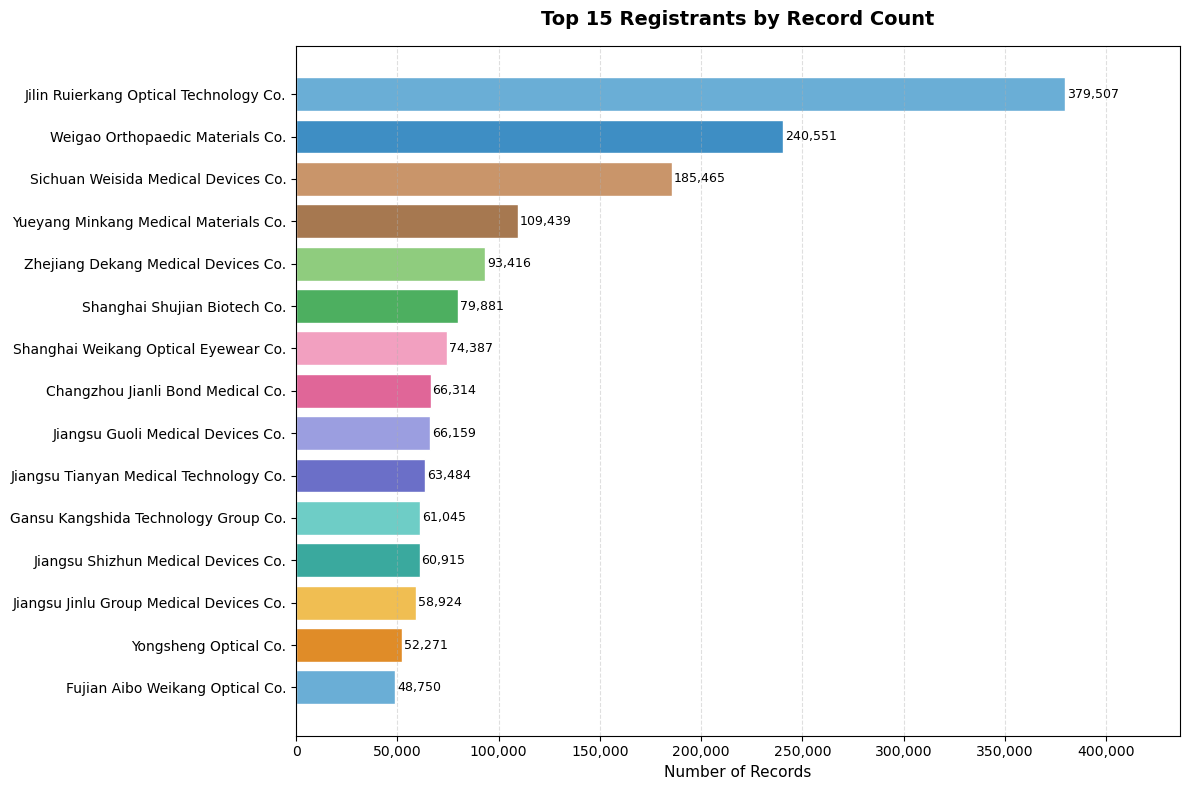

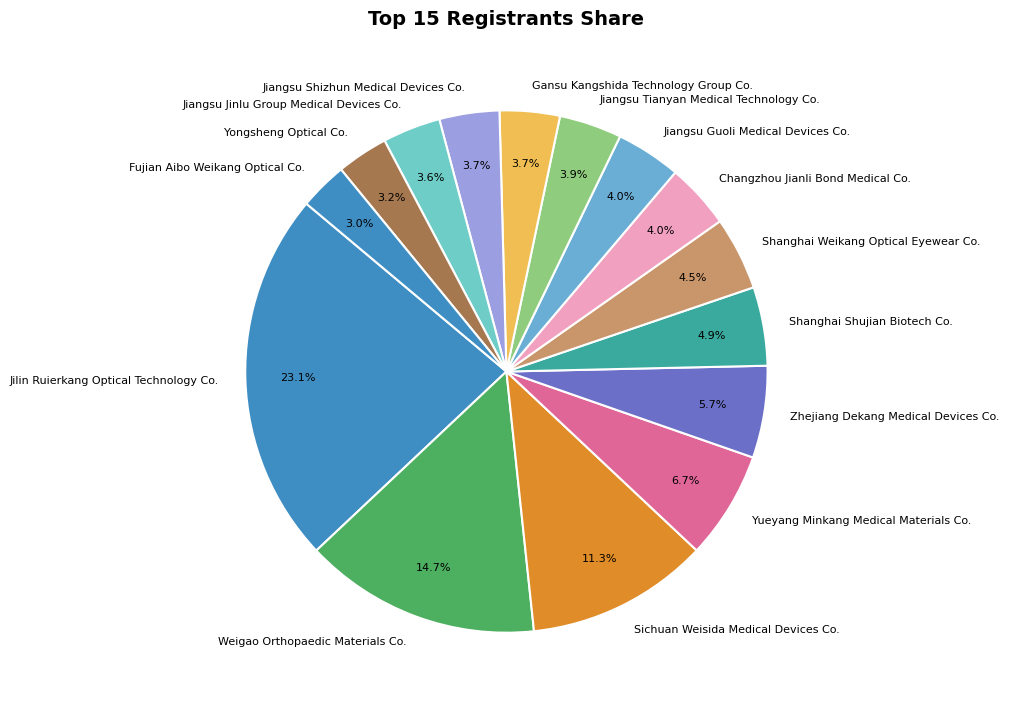

In [101]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd
import sqlite3

conn = sqlite3.connect("../database/chinese_medical_devices.db")
top_reg = pd.read_sql("""
    SELECT
        registrant_name_cn,
        COUNT(*) AS count
    FROM devices
    WHERE registrant_name_cn IS NOT NULL
    GROUP BY registrant_name_cn
    ORDER BY count DESC
    LIMIT 15
""", conn)
conn.close()

# English name mapping
name_mapping = {
    '吉林瑞尔康光学科技有限公司':   'Jilin Ruierkang Optical Technology Co.',
    '山东威高骨科材料股份有限公司': 'Weigao Orthopaedic Materials Co.',
    '四川维思达医疗器械有限公司':   'Sichuan Weisida Medical Devices Co.',
    '岳阳民康医用材料有限公司':     'Yueyang Minkang Medical Materials Co.',
    '浙江德康医疗器械有限公司':     'Zhejiang Dekang Medical Devices Co.',
    '上海数健生物科技有限公司':     'Shanghai Shujian Biotech Co.',
    '上海卫康光学眼镜有限公司':     'Shanghai Weikang Optical Eyewear Co.',
    '常州健力邦德医疗器械有限公司': 'Changzhou Jianli Bond Medical Co.',
    '江苏国立医疗器械有限公司':     'Jiangsu Guoli Medical Devices Co.',
    '江苏天眼医药科技股份有限公司': 'Jiangsu Tianyan Medical Technology Co.',
    '甘肃康视达科技集团有限公司':   'Gansu Kangshida Technology Group Co.',
    '江苏视准医疗器械有限公司':     'Jiangsu Shizhun Medical Devices Co.',
    '江苏金鹿集团医疗器械有限公司': 'Jiangsu Jinlu Group Medical Devices Co.',
    '永胜光学股份有限公司':         'Yongsheng Optical Co.',
    '福建爱博维康光学有限公司':     'Fujian Aibo Weikang Optical Co.',
}

top_reg['registrant_name_en'] = top_reg['registrant_name_cn'].map(name_mapping)
top_reg.index = range(1, len(top_reg) + 1)

display(top_reg[['registrant_name_en', 'count']])

# Darker colors
bar_colors = [
    "#6AAED6", "#3E8EC4", "#C9956A", "#A67850",
    "#8FCC7E", "#4DAF60", "#F2A0C0", "#E06698",
    "#9B9EE0", "#6B6FC8", "#6ECDC6", "#3AA99E",
    "#F0BE52", "#E08C28", "#6AAED6"
]

pie_colors = [
    "#3E8EC4", "#4DAF60", "#E08C28", "#E06698",
    "#6B6FC8", "#3AA99E", "#C9956A", "#F2A0C0",
    "#6AAED6", "#8FCC7E", "#F0BE52", "#9B9EE0",
    "#6ECDC6", "#A67850", "#3E8EC4"
]

# --- Bar chart ---
fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.barh(
    top_reg['registrant_name_en'][::-1],
    top_reg['count'][::-1],
    color=bar_colors[::-1],
    edgecolor='white'
)

# Add value labels
for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 1000,
        bar.get_y() + bar.get_height() / 2,
        f"{int(width):,}",
        va='center', ha='left', fontsize=9
    )

ax.set_title("Top 15 Registrants by Record Count", fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Number of Records", fontsize=11)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.grid(axis="x", linestyle="--", alpha=0.4)
# Add extra space on right for labels
ax.set_xlim(0, top_reg['count'].max() * 1.15)
plt.tight_layout()
plt.savefig("../outputs/top15_registrants_bar.png", dpi=300, bbox_inches="tight")
plt.show()

# --- Pie chart ---
fig, ax = plt.subplots(figsize=(10, 10))
wedges, texts, autotexts = ax.pie(
    top_reg['count'],
    labels=top_reg['registrant_name_en'],
    autopct="%1.1f%%",
    startangle=140,
    colors=pie_colors,
    wedgeprops={"edgecolor": "white", "linewidth": 1.5},
    pctdistance=0.8
)
for t in texts:
    t.set_fontsize(8)
for t in autotexts:
    t.set_fontsize(8)
ax.set_title("Top 15 Registrants Share", fontsize=14, fontweight="bold", pad=15)
plt.tight_layout()
plt.savefig("../outputs/top15_registrants_pie.png", dpi=300, bbox_inches="tight")
plt.show()

#### 4.2 Approval Type Distribution

In [37]:
conn = sqlite3.connect("../database/chinese_medical_devices.db")

reg_type = pd.read_sql("""
    SELECT
        CASE
            WHEN registration_or_filing_number LIKE '%注进%'
                THEN 'Imported (Registration)'
            WHEN registration_or_filing_number LIKE '%注准%'
                THEN 'Domestic (Registration)'
            WHEN registration_or_filing_number LIKE '%械备%'
                THEN 'Filing (Domestic/Imported)'
            ELSE 'Other / Unknown'
        END AS approval_type,
        COUNT(*) AS count
    FROM devices
    WHERE registration_or_filing_number IS NOT NULL
    GROUP BY approval_type
    ORDER BY count DESC
""", conn)

conn.close()
display(reg_type)

,approval_type,count
0,Domestic (Registration),4671284
1,Imported (Registration),573734
2,Filing (Domestic/Imported),267670
3,Other / Unknown,160886


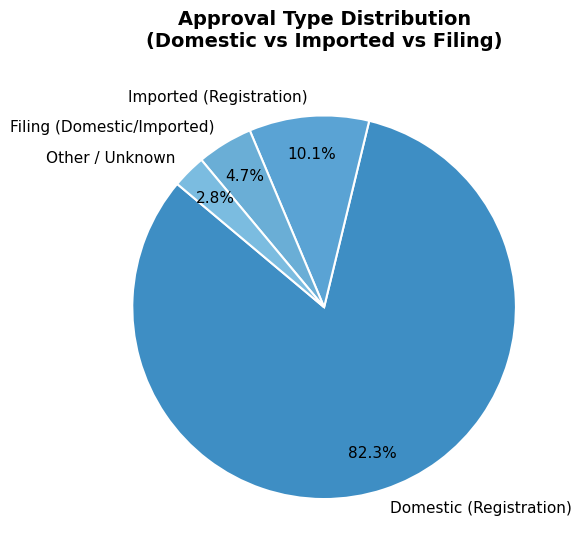

In [103]:
fig, ax = plt.subplots(figsize=(6, 6))

pie_colors = [  "#3E8EC4", "#5AA3D4", "#6AAED6", "#7BBCE0"]

wedges, texts, autotexts = ax.pie(
    reg_type["count"],
    labels=reg_type["approval_type"],
    autopct="%1.1f%%",
    startangle=140,
    colors=pie_colors,
    wedgeprops={"edgecolor": "white", "linewidth": 1.5},
    pctdistance=0.8
)
for t in texts:
    t.set_fontsize(11)
for t in autotexts:
    t.set_fontsize(11)

ax.set_title("Approval Type Distribution\n(Domestic vs Imported vs Filing)",
             fontsize=14, fontweight="bold", pad=15)
plt.tight_layout()
plt.savefig("../outputs/approval_type_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

#### 4.3 Top 10 Approving Provinces

In [60]:
conn = sqlite3.connect("../database/chinese_medical_devices.db")

province_raw = pd.read_sql("""
    SELECT
        SUBSTR(registration_or_filing_number, 1, 1) AS province_code,
        COUNT(*) AS count
    FROM devices
    WHERE registration_or_filing_number IS NOT NULL
    GROUP BY province_code
    ORDER BY count DESC
    LIMIT 10
""", conn)

conn.close()
print(province_raw.to_string(index=False))

province_code   count
            国 4311508
            苏  287074
            粤  159596
            浙  154122
            川  116710
            鲁   89093
            湘   82381
            京   67619
            沪   51070
            豫   46605


       province   count
National (NMPA) 4311508
        Jiangsu  287074
      Guangdong  159596
       Zhejiang  154122
        Sichuan  116710
       Shandong   89093
          Hunan   82381
        Beijing   67619
       Shanghai   51070
          Henan   46605


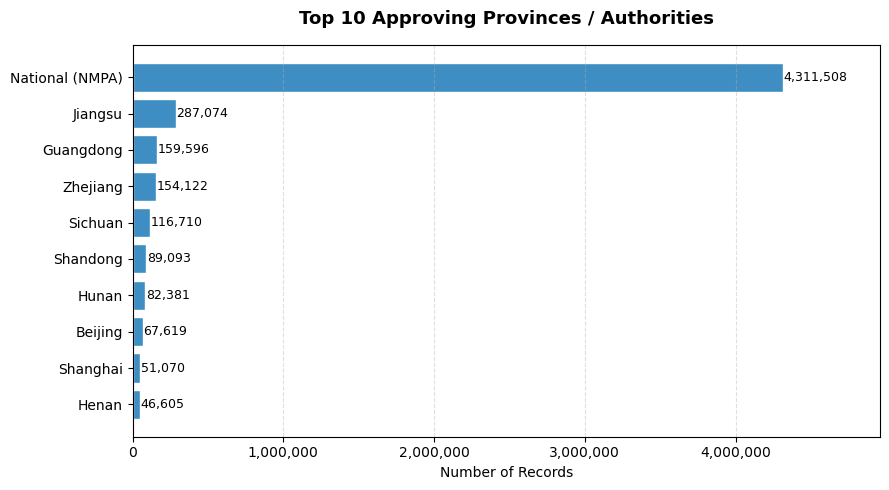

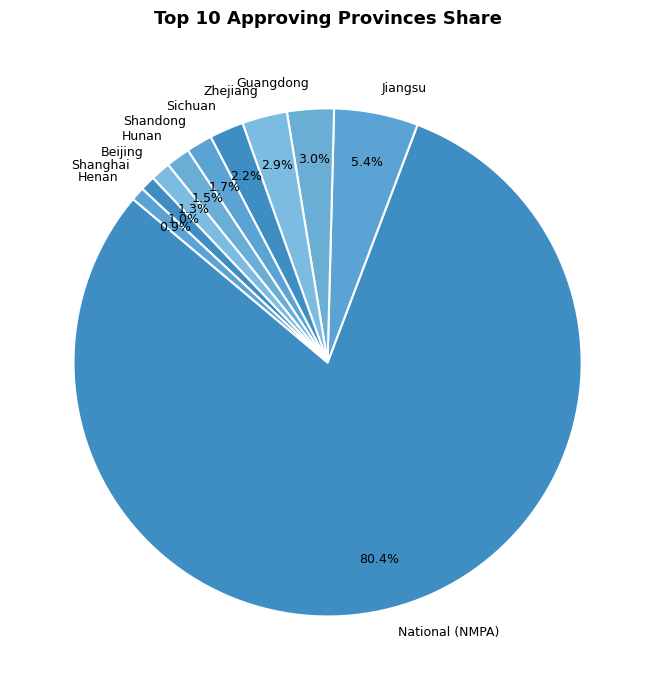

In [129]:
province_map = {
    "国": "National (NMPA)",
    "苏": "Jiangsu",
    "粤": "Guangdong",
    "浙": "Zhejiang",
    "川": "Sichuan",
    "鲁": "Shandong",
    "湘": "Hunan",
    "京": "Beijing",
    "沪": "Shanghai",
    "豫": "Henan",
}

province_raw["province"] = province_raw["province_code"].map(province_map)
print(province_raw[["province", "count"]].to_string(index=False))

# --- Bar chart ---
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(
    province_raw["province"][::-1],
    province_raw["count"][::-1],
    color="#3E8EC4",
    edgecolor="white"
)

for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 5000,
        bar.get_y() + bar.get_height() / 2,
        f"{int(width):,}",
        va="center", ha="left", fontsize=9
    )

ax.set_title("Top 10 Approving Provinces / Authorities",
             fontsize=13, fontweight="bold", pad=15)
ax.set_xlabel("Number of Records", fontsize=10)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.grid(axis="x", linestyle="--", alpha=0.4)
ax.set_xlim(0, province_raw["count"].max() * 1.15)
plt.tight_layout()
plt.savefig("../outputs/top10_provinces_bar.png", dpi=300, bbox_inches="tight")
plt.show()

# --- Pie chart ---
pie_colors_provinces = [
    "#2C5F8A", "#3A7CA5", "#4A90B8", "#5BA3C9",
    "#2E7D5E", "#3D9970", "#4DAF82", "#C0392B",
    "#E05A4A", "#E8836A"
]

fig, ax = plt.subplots(figsize=(7, 7))
wedges, texts, autotexts = ax.pie(
    province_raw["count"],
    labels=province_raw["province"],
    autopct="%1.1f%%",
    startangle=140,
    colors=pie_colors,
    wedgeprops={"edgecolor": "white", "linewidth": 1.5},
    pctdistance=0.8
)
for t in texts:
    t.set_fontsize(9)
for t in autotexts:
    t.set_fontsize(9)
ax.set_title("Top 10 Approving Provinces Share",
             fontsize=13, fontweight="bold", pad=15)
plt.tight_layout()
plt.savefig("../outputs/top10_provinces_pie.png", dpi=300, bbox_inches="tight")
plt.show()